## Aim 

In this code, the Land Surface Temperature data (LST) using band 10 at the ward level are merged with the road characteristics. In this code, the LST is used but it is masked for water pixels as not masking can distort the computation of the mean LST per ward. Please see also Chakraborty (2023) for similar arguments.

In [1]:
from pathlib import Path

## import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import linregress, pearsonr
from sklearn.linear_model import LinearRegression

## Reading in the data

In [2]:
# Define the paths
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = BASE_DIR / "images"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


### Land Surface Temperature

In [19]:
lst_path = PROCESSED_DIR /'lstband10summer_chennai_masked.csv'
print(lst_path)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstband10summer_chennai_masked.csv


In [20]:
df_lst_mean_summer = pd.read_csv(lst_path)

In [21]:
df_lst_mean_summer.head()

,system:index,zone_id,mean,zone_name,Name
0,0,13,40.406214,Adyar,168
1,1,13,39.307642,Adyar,169
2,2,13,37.885066,Adyar,170
3,3,13,38.209922,Adyar,171
4,4,13,37.721421,Adyar,174


In [22]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 37.05533728957053.
The maximum temperature is 44.50043073157101.


### Road density

In [23]:
road_density_path = PROCESSED_DIR /'results_chennai_all_roads.csv'
df_road_density = pd.read_csv(road_density_path)

In [24]:
df_road_density.head()

,Unnamed: 0,Name,zone_id,zone_name,street_length,street_density,area
0,0,168,13,Adyar,75169.504436,21098.044012,3.562866e+06
1,1,169,13,Adyar,73317.480822,19458.220252,3.767944e+06
2,2,170,13,Adyar,49375.041995,18280.088566,2.701029e+06
3,3,171,13,Adyar,54634.286214,16309.207438,3.349904e+06
4,4,174,13,Adyar,52844.744254,15261.443669,3.462631e+06


In [25]:
merged = pd.merge(df_lst_mean_summer, df_road_density, on='Name')
merged.head()

,system:index,zone_id_x,mean,zone_name_x,Name,Unnamed: 0,zone_id_y,zone_name_y,street_length,street_density,area
0,0,13,40.406214,Adyar,168,0,13,Adyar,75169.504436,21098.044012,3.562866e+06
1,1,13,39.307642,Adyar,169,1,13,Adyar,73317.480822,19458.220252,3.767944e+06
2,2,13,37.885066,Adyar,170,2,13,Adyar,49375.041995,18280.088566,2.701029e+06
3,3,13,38.209922,Adyar,171,3,13,Adyar,54634.286214,16309.207438,3.349904e+06
4,4,13,37.721421,Adyar,174,4,13,Adyar,52844.744254,15261.443669,3.462631e+06


Only retain the relevant variables and rename:

In [26]:
merged = merged[['zone_id_x', 'mean', 'zone_name_x', 'Name', 'street_length', 'street_density', 'area']]
merged.head()

,zone_id_x,mean,zone_name_x,Name,street_length,street_density,area
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06


In [27]:
# Rename the columns
merged = merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name',
    'mean': 'mean_lst'
})
merged.head()

,zone_id,mean_lst,zone_name,Name,street_length,street_density,area
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06


In [28]:
print(f'The mininim street density is {merged["street_density"].min()} metres or {merged["street_density"].min()/1000} km per square km.')
print(f'The maximimum street density is {merged["street_density"].max()} metres or {merged["street_density"].max()/1000} km per square km.')

The mininim street density is 4316.475561270958 metres or 4.316475561270957 km per square km.
The maximimum street density is 31796.66127820001 metres or 31.79666127820001 km per square km.


In [29]:
# index of min and max street density
idx_min = merged["street_density"].idxmin()
idx_max = merged["street_density"].idxmax()

In [30]:
# ward names
ward_min = merged.loc[idx_min, "Name"]
ward_max = merged.loc[idx_max, "Name"]

In [31]:
print(f' The ward with the minimum street density is {ward_min} and the maximum street density is {ward_max}.')

 The ward with the minimum street density is 159 and the maximum street density is 47.


#### Street density

In [32]:
fig_path = IMAGES_DIR / 'regression_chennai_street_density_masked.png'

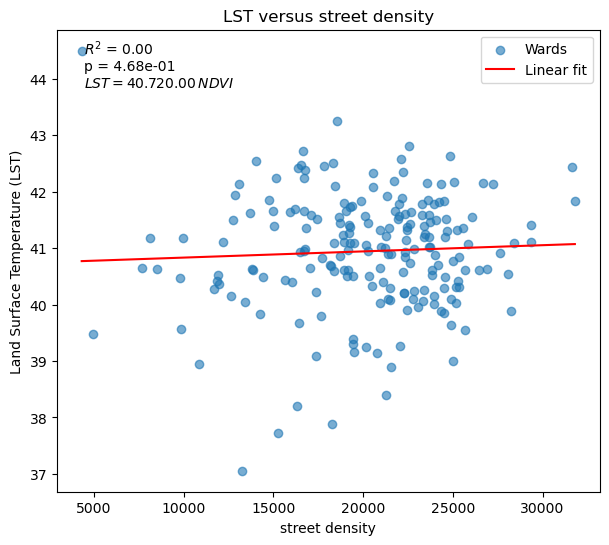

In [33]:
# x and y
x = merged["street_density"]
y = merged["mean_lst"]

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("street density")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus street density")
plt.legend()

# annotation
plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,NDVI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


In [34]:
p_value

np.float64(0.46821709999824557)

In [35]:
print(slope, intercept, r_value)

1.0996850496134739e-05 40.7233078035549 0.051581481032913365


In [36]:
pearsonr(merged['street_density'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.05158148103291335), pvalue=np.float64(0.46821709999824473))

In [37]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['street_density']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.5282
Date:                Thu, 15 Jan 2026   Prob (F-statistic):              0.468
Time:                        18:04:19   Log-Likelihood:                -287.81
No. Observations:                 200   AIC:                             579.6
Df Residuals:                     198   BIC:                             586.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             40.7233      0.315    129.

In [38]:
pearsonr(merged['street_density'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.05158148103291335), pvalue=np.float64(0.46821709999824473))

#### Straightness

In [39]:
straightness_path = PROCESSED_DIR /'results_chennai_straightness_all_roads.csv'
df_straightness = pd.read_csv(straightness_path)

In [40]:
df_straightness.head()

,Unnamed: 0,Name,zone_id,zone_name,straightness
0,0,168,13,Adyar,0.674565
1,1,169,13,Adyar,0.581726
2,2,170,13,Adyar,0.687670
3,3,171,13,Adyar,0.734294
4,4,174,13,Adyar,0.706802


In [41]:
merged = pd.merge(merged, df_straightness, on='Name')
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,Unnamed: 0,zone_id_y,zone_name_y,straightness
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06,0,13,Adyar,0.674565
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06,1,13,Adyar,0.581726
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06,2,13,Adyar,0.687670
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06,3,13,Adyar,0.734294
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06,4,13,Adyar,0.706802


In [42]:
merged = merged[['zone_id_x', 'mean_lst', 'zone_name_x', 'Name','street_length', 'street_density', 'area', 'straightness']]
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,straightness
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06,0.674565
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06,0.581726
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06,0.687670
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06,0.734294
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06,0.706802


In [45]:
# x and y
x = merged["straightness"]
y = merged["mean_lst"]

In [46]:
fig_path = IMAGES_DIR / 'regression_chennai_straightness_masked.png'

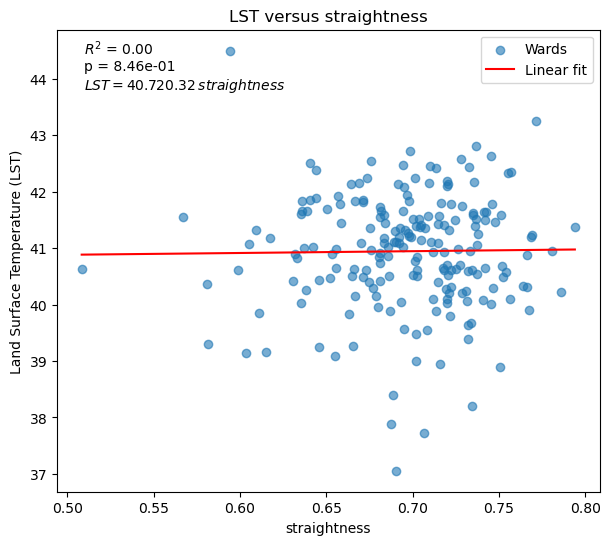

In [47]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("straightness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus straightness")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,straightness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [48]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['straightness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                   0.03768
Date:                Thu, 15 Jan 2026   Prob (F-statistic):              0.846
Time:                        18:05:16   Log-Likelihood:                -288.06
No. Observations:                 200   AIC:                             580.1
Df Residuals:                     198   BIC:                             586.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           40.7239      1.145     35.561   

In [49]:
pearsonr(merged['straightness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.013793848439940463), pvalue=np.float64(0.8462847512584679))

#### Global closeness

In [50]:
global_closeness_path = PROCESSED_DIR /'results_chennai_global_closeness_all_roads.csv'
df_global_closeness = pd.read_csv(global_closeness_path)

In [51]:
df_global_closeness.head()

,Unnamed: 0,Name,zone_id,zone_name,closeness
0,0,168,13,Adyar,0.000671
1,1,169,13,Adyar,0.000464
2,2,170,13,Adyar,0.000558
3,3,171,13,Adyar,0.000818
4,4,174,13,Adyar,0.000814


In [52]:
merged = pd.merge(merged, df_global_closeness, on='Name')
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,straightness,Unnamed: 0,zone_id,zone_name,closeness
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06,0.674565,0,13,Adyar,0.000671
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06,0.581726,1,13,Adyar,0.000464
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06,0.687670,2,13,Adyar,0.000558
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06,0.734294,3,13,Adyar,0.000818
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06,0.706802,4,13,Adyar,0.000814


In [53]:
merged = merged[['zone_id_x', 'mean_lst', 'zone_name_x', 'Name', 'street_length', 'street_density', 'area', 'straightness', 'closeness']]
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,straightness,closeness
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06,0.674565,0.000671
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06,0.581726,0.000464
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06,0.687670,0.000558
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06,0.734294,0.000818
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06,0.706802,0.000814


In [54]:
# Rename the columns
merged = merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name',
    'closeness': 'global_closeness'
})
merged.head()

,zone_id,mean_lst,zone_name,Name,street_length,street_density,area,straightness,global_closeness
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06,0.674565,0.000671
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06,0.581726,0.000464
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06,0.687670,0.000558
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06,0.734294,0.000818
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06,0.706802,0.000814


In [55]:
# x and y
x = merged["global_closeness"]
y = merged["mean_lst"]

In [56]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [57]:
fig_path = IMAGES_DIR / 'regression_chennai_global_closeness_masked.png'

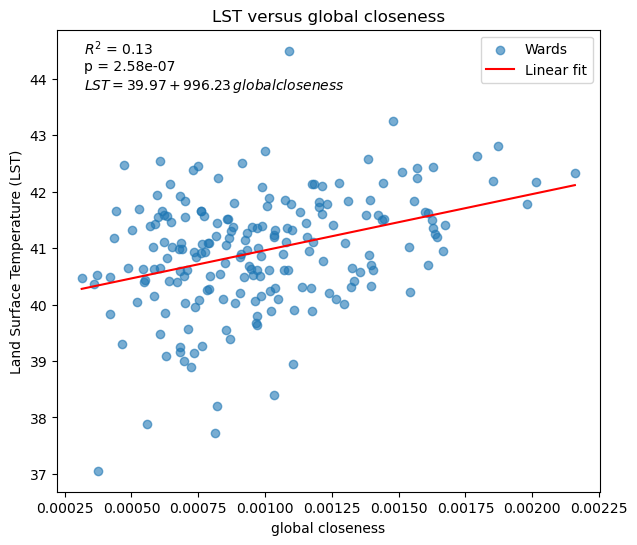

In [58]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("global closeness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus global closeness")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,global closeness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [59]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['global_closeness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     28.47
Date:                Thu, 15 Jan 2026   Prob (F-statistic):           2.58e-07
Time:                        18:05:56   Log-Likelihood:                -274.64
No. Observations:                 200   AIC:                             553.3
Df Residuals:                     198   BIC:                             559.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               39.9666      0.196  

In [60]:
pearsonr(merged['global_closeness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.35458364424125177), pvalue=np.float64(2.5840107117745854e-07))

#### Local closeness

In [61]:
local_closeness_path = PROCESSED_DIR /'results_chennai_local_closeness_all_roads.csv'
df_local_closeness = pd.read_csv(local_closeness_path)
df_local_closeness.head()

,Unnamed: 0,Name,zone_id,zone_name,closeness_local
0,0,168,13,Adyar,0.000292
1,1,169,13,Adyar,0.000234
2,2,170,13,Adyar,0.000347
3,3,171,13,Adyar,0.000412
4,4,174,13,Adyar,0.000360


In [62]:
merged = pd.merge(merged, df_local_closeness, on='Name')
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,straightness,global_closeness,Unnamed: 0,zone_id_y,zone_name_y,closeness_local
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06,0.674565,0.000671,0,13,Adyar,0.000292
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06,0.581726,0.000464,1,13,Adyar,0.000234
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06,0.687670,0.000558,2,13,Adyar,0.000347
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06,0.734294,0.000818,3,13,Adyar,0.000412
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06,0.706802,0.000814,4,13,Adyar,0.000360


In [63]:
merged = merged[['zone_id_x', 'mean_lst', 'zone_name_x','Name', 'street_length', 'street_density', 'area', 'straightness', 'global_closeness', 'closeness_local']]
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,straightness,global_closeness,closeness_local
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06,0.674565,0.000671,0.000292
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06,0.581726,0.000464,0.000234
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06,0.687670,0.000558,0.000347
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06,0.734294,0.000818,0.000412
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06,0.706802,0.000814,0.000360


In [64]:
# Rename the columns
merged = merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name',
    'closeness_local': 'local_closeness'
})
merged.head()

,zone_id,mean_lst,zone_name,Name,street_length,street_density,area,straightness,global_closeness,local_closeness
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06,0.674565,0.000671,0.000292
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06,0.581726,0.000464,0.000234
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06,0.687670,0.000558,0.000347
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06,0.734294,0.000818,0.000412
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06,0.706802,0.000814,0.000360


In [65]:
# x and y
x = merged["local_closeness"]
y = merged["mean_lst"]

In [52]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [66]:
fig_path = IMAGES_DIR / 'regression_chennai_local_closeness_masked.png'

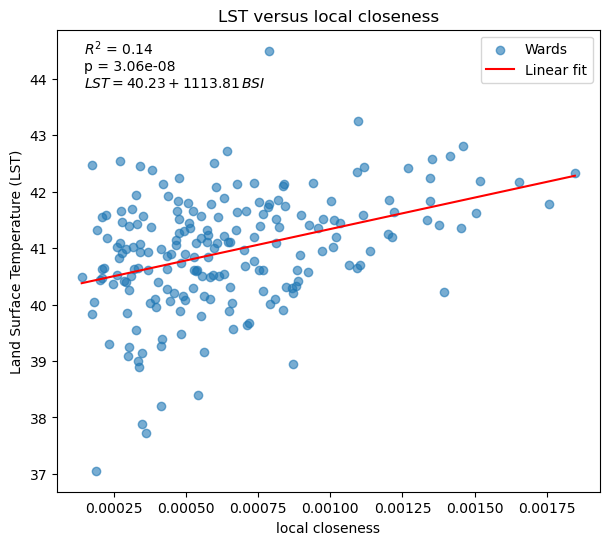

In [67]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("local closeness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus local closeness")
plt.legend()


# annotation


plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,BSI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [68]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['local_closeness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     33.26
Date:                Thu, 15 Jan 2026   Prob (F-statistic):           3.06e-08
Time:                        18:08:31   Log-Likelihood:                -272.55
No. Observations:                 200   AIC:                             549.1
Df Residuals:                     198   BIC:                             555.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              40.2262      0.142    2

In [69]:
pearsonr(merged['local_closeness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.37923728931103473), pvalue=np.float64(3.061639586810087e-08))

In [70]:
merged

,zone_id,mean_lst,zone_name,Name,street_length,street_density,area,straightness,global_closeness,local_closeness
0,13,40.406214,Adyar,168,75169.504436,21098.044012,3.562866e+06,0.674565,0.000671,0.000292
1,13,39.307642,Adyar,169,73317.480822,19458.220252,3.767944e+06,0.581726,0.000464,0.000234
2,13,37.885066,Adyar,170,49375.041995,18280.088566,2.701029e+06,0.687670,0.000558,0.000347
3,13,38.209922,Adyar,171,54634.286214,16309.207438,3.349904e+06,0.734294,0.000818,0.000412
4,13,37.721421,Adyar,174,52844.744254,15261.443669,3.462631e+06,0.706802,0.000814,0.000360
...,...,...,...,...,...,...,...,...,...,...
195,9,39.262336,Teynampet,110,45308.674095,22062.191786,2.053680e+06,0.665672,0.000764,0.000413
196,12,41.653612,Alandur,161,13211.312827,16730.798360,7.896403e+05,0.681640,0.000762,0.000708
197,12,41.648215,Alandur,160,10652.094770,15903.379548,6.698007e+05,0.742446,0.001597,0.001221
198,15,39.854800,Sholinganallur,195,61005.764641,24514.119499,2.488597e+06,0.611279,0.000625,0.000293


## Correlation

In [72]:
vars_df = merged[[
    "mean_lst",
    "street_density",
    "straightness",
    "global_closeness",
    "local_closeness"
]].dropna()

In [73]:
corr = vars_df.corr(method="pearson")

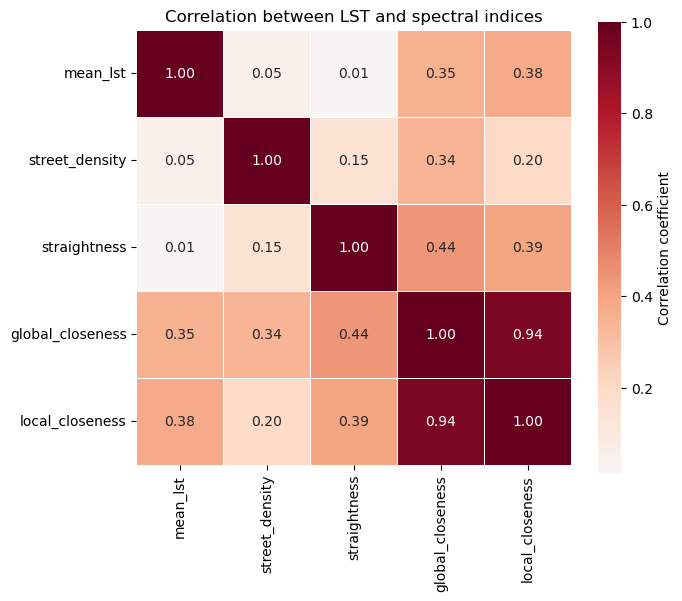

In [74]:
corr_path_indices = IMAGES_DIR / 'corr_indices_chennai_masked.png'
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between LST and spectral indices")
plt.tight_layout()
plt.savefig(corr_path_indices, dpi=300, bbox_inches="tight")
plt.show()

## References

T. Chakraborty, “Heat islands,” in Cloud-based remote sensing with Google Earth Engine, J. A. Cardille, M. A. Crowley, D. Saah and N. E. Clinton, Eds. Springer Open, 2023 [Online] Available: https://link.springer.com/book/10.1007/978-3-031-26588-4